In [28]:
import torch
import torch.nn as nn
import torch.optim as optim

import helper_utils

In [29]:
# Combined dataset: bikes for short distances, cars for longer ones
distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

# Corresponding delivery times in minutes
times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

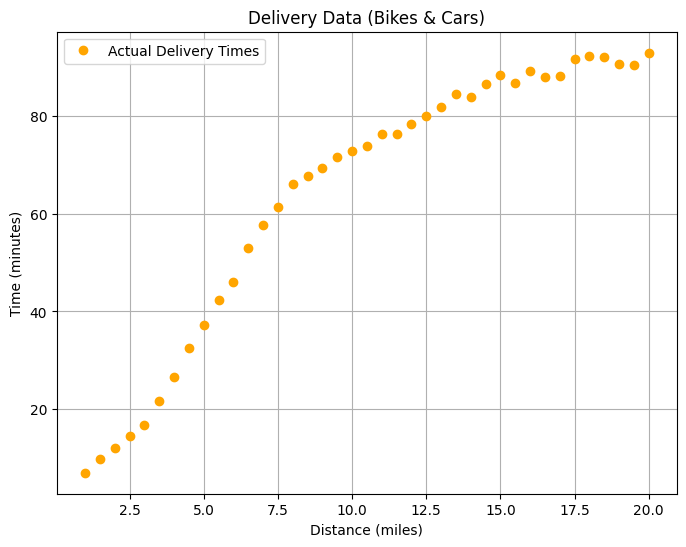

In [30]:
helper_utils.plot_data(distances, times)

In [31]:
# normalize the data
distance_mean = distances.mean()
distance_std = distances.std()

times_mean = times.mean()
times_std = times.std()

distances_norm = (distances - distance_mean) / distance_std
times_norm = (times - times_mean) / times_std

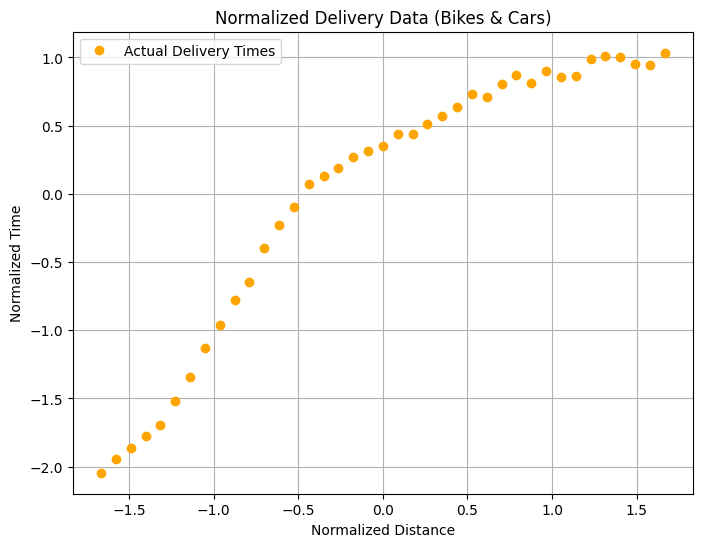

In [32]:
helper_utils.plot_data(distances_norm, times_norm, normalize=True)

In [33]:
torch.manual_seed(26)

model = nn.Sequential(
    nn.Linear(1,3),
    nn.ReLU(),
    nn.Linear(3,1)
)

loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

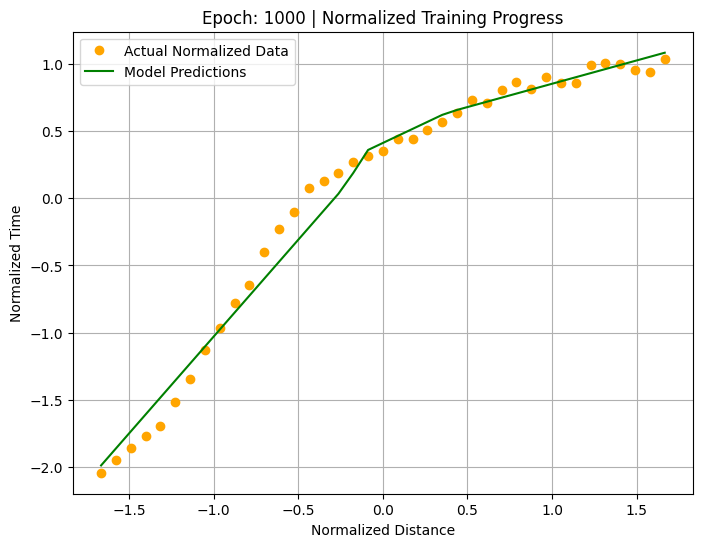


Training Complete.

Final Loss: 0.01378348097205162


In [34]:
for epoch in range(1000):
    optimizer.zero_grad()
    predicted = model(distances_norm)
    loss = loss_function(times_norm, predicted)
    loss.backward()
    optimizer.step()
    
    # Create a live plot every 50 epochs
    if (epoch + 1) % 50 == 0:
        helper_utils.plot_training_progress(
            epoch=epoch,
            loss=loss,
            model=model,
            distances_norm=distances_norm,
            times_norm=times_norm
        )

print("\nTraining Complete.")
print(f"\nFinal Loss: {loss.item()}")

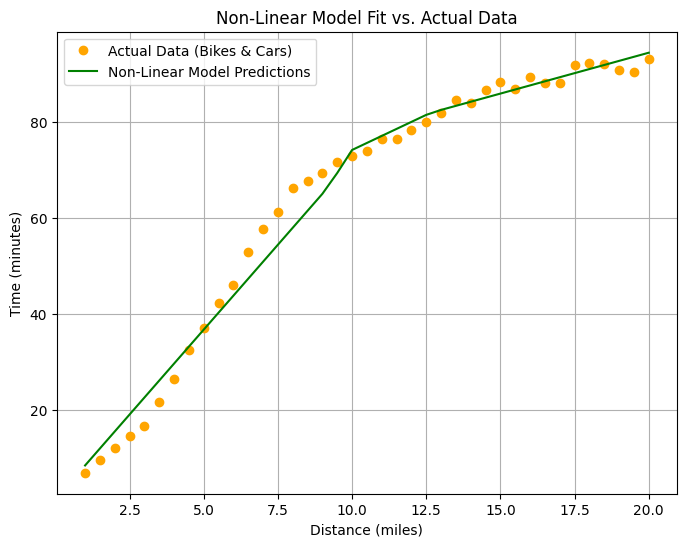

In [35]:
helper_utils.plot_final_fit(model, distances, times, distances_norm, times_std, times_mean)

In [36]:
# Prediction

distance_to_predict = 5.1

distance_tensor = torch.tensor([[distance_to_predict]], dtype=torch.float32)
new_distance_norm = (distance_tensor-distance_mean) / distance_std

with torch.no_grad():
    predicted_time_norm = model(new_distance_norm)
    predicted_time_actual = (predicted_time_norm*times_std) + times_mean

# --- Decision Making Logic ---
print(f"Prediction for a {distance_to_predict}-mile delivery: {predicted_time_actual.item():.1f} minutes")

# First, check if the delivery is possible within the 45-minute timeframe
if predicted_time_actual.item() > 45:
    print("\nDecision: Do NOT promise the delivery in under 45 minutes.")
else:
    # If it is possible, then determine the vehicle based on the distance
    if distance_to_predict <= 3:
        print(f"\nDecision: Yes, delivery is possible. Since the distance is {distance_to_predict} miles (<= 3 miles), use a bike.")
    else:
        print(f"\nDecision: Yes, delivery is possible. Since the distance is {distance_to_predict} miles (> 3 miles), use a car.") 

Prediction for a 5.1-mile delivery: 37.5 minutes

Decision: Yes, delivery is possible. Since the distance is 5.1 miles (> 3 miles), use a car.
